In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import networkx as nx
import scipy.sparse.linalg as spla
import random

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.cm as cm

from k_regular_graph_generator import generate_multiple_k_regular_graphs
from ql_bit_generator import generate_quantum_like_bit, visualize_ql_bit
from eigenvalue_analysis import *
from bell_state_generation import *
from cartesian_prod_complete import *

np.set_printoptions(
    threshold=15000,      # Total number of array elements to display
    linewidth=200,        # Number of characters per line (increase for longer rows)
    suppress=True,        # Suppress scientific notation for small numbers
    precision=3,          # Number of digits of precision for floating point
    edgeitems=10         # Number of items at beginning and end of each dimension
)

In [8]:
coupled_matrix_a, info = generate_quantum_like_bit(40, 34, 40, 34, 1)

P_cart = nx.cartesian_product(nx.from_numpy_array(coupled_matrix_a), nx.from_numpy_array(coupled_matrix_a))
# P_1_cart = nx.cartesian_product(P_cart, nx.from_numpy_array(coupled_matrix_a))
# P_2_cart = nx.cartesian_product(P_1_cart, nx.from_numpy_array(coupled_matrix_a))

# P = nx.cartesian_product(nx.from_numpy_array(coupled_matrix_a), nx.complete_graph(2))
# P_1 = nx.cartesian_product(P, nx.complete_graph(2))
# P_2 = nx.cartesian_product(P_1, nx.complete_graph(2))
# P_3 = nx.cartesian_product(P_2, nx.complete_graph(2))

P = nx.cartesian_product(nx.complete_graph(2), nx.complete_graph(2))
P_1 = nx.cartesian_product(P, nx.complete_graph(2))
P_2 = nx.cartesian_product(P_1, nx.complete_graph(2))
P_3 = nx.cartesian_product(P_2, nx.complete_graph(2))
P_4 = nx.cartesian_product(P_3, nx.complete_graph(2))
P_5 = nx.cartesian_product(P_4, nx.complete_graph(2))
P_6 = nx.cartesian_product(P_5, nx.complete_graph(2))
P_7 = nx.cartesian_product(P_6, nx.complete_graph(2))
P_8 = nx.cartesian_product(P_7, nx.complete_graph(2))
P_9 = nx.cartesian_product(P_8, nx.complete_graph(2))
P_10 = nx.cartesian_product(P_9, nx.complete_graph(2))

In [10]:
# Get adjacency matrix
adj_matrix_cart = coupled_matrix_a

# # Compute eigenvalues and eigenvectors
eigenvalues_cart, eigenvectors_cart = np.linalg.eigh(adj_matrix_cart)

# # Sort by eigenvalue magnitude
idx = np.abs(eigenvalues_cart).argsort()[::-1]
eigenvalues_cart = eigenvalues_cart[idx]
eigenvectors_cart = eigenvectors_cart[:, idx]

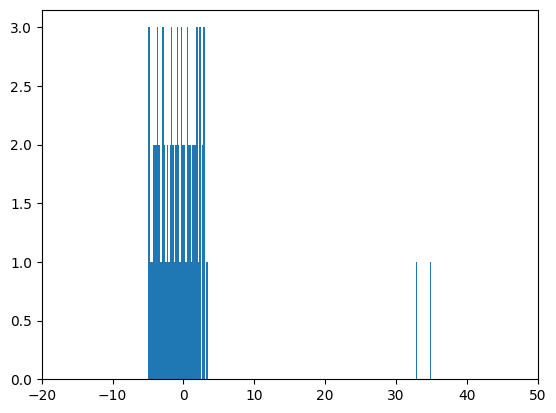

[35.    33.    -4.962 -4.826 -4.774 -4.666 -4.532 -4.326 -4.292 -4.148]


In [11]:
plt.hist(eigenvalues_cart, bins=200)
plt.xlim(-20, 50)
plt.show()
print(eigenvalues_cart[:10])

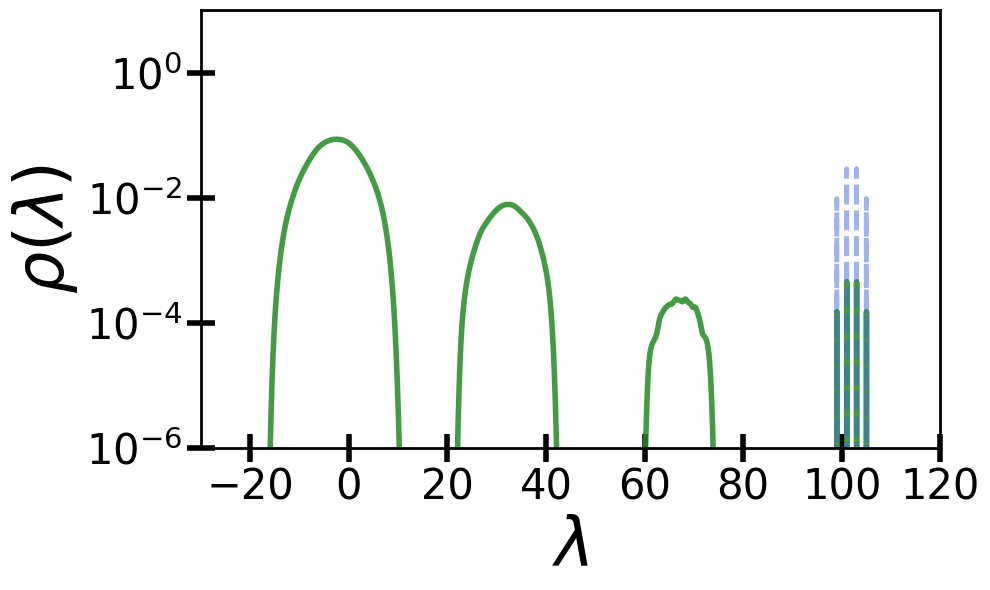

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import networkx as nx
from scipy.ndimage import gaussian_filter1d

def get_base_components(adj_matrix, x_min, x_max, bins, num_emergent):
    """Separates the initial spectrum into two distinct arrays."""
    evs = np.linalg.eigvalsh(adj_matrix)
    n_total = len(evs)
    sorted_evs = np.sort(evs)
    
    emergent_evs = sorted_evs[-num_emergent:]
    bulk_evs = sorted_evs[:-num_emergent]
    
    bin_edges = np.linspace(x_min, x_max, bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    dx = bin_centers[1] - bin_centers[0]
    
    # Initial Bulk (not smoothed yet)
    rho_bulk, _ = np.histogram(bulk_evs, bins=bin_edges)
    rho_bulk = (rho_bulk.astype(float) / n_total) / dx
    
    # Initial Emergent
    rho_em = np.zeros_like(bin_centers)
    for ev in emergent_evs:
        idx = np.argmin(np.abs(bin_centers - ev))
        rho_em[idx] += (1.0 / n_total) / dx
        
    return bin_centers, rho_bulk, rho_em, dx

def generate_clean_spectrum(adj_matrix, n_bits=1, num_emergent=2, 
                            x_range=(-30, 100), bins=8000, sigma=50.0):
    """
    Convolves bulk and emergent states separately to prevent 
    spikes from 'contaminating' the smooth bulk humps.
    """
    x, b, e, dx = get_base_components(adj_matrix, x_range[0], x_range[1], bins, num_emergent)
    
    curr_bulk = b
    curr_em = e
    
    for _ in range(1, n_bits):
        # New Emergent: Only emergent * emergent stays sharp
        new_em = np.convolve(curr_em, e, mode='full') * dx
        
        # New Bulk: (Bulk * Bulk) + (Bulk * Emergent)
        # All of these terms should be smooth
        term1 = np.convolve(curr_bulk, b, mode='full') * dx
        term2 = np.convolve(curr_bulk, e, mode='full') * dx
        term3 = np.convolve(curr_em, b, mode='full') * dx
        new_bulk = term1 + term2 + term3
        
        curr_bulk = new_bulk
        curr_em = new_em
    
    # Apply Gaussian filter ONLY to the bulk component
    if sigma > 0:
        curr_bulk = gaussian_filter1d(curr_bulk, sigma=sigma)
        
    rho_total = curr_bulk + curr_em
    x_axis = np.linspace(x_range[0] * n_bits, x_range[1] * n_bits, len(rho_total))
    
    return x_axis, rho_total

# --- Plotting ---
bins_res = 10000 
# For coupled_matrix_a only change n_bits, as num_emergent is per QL-bit
# nx.to_numpy_array(P_1) num_emergent should be num_emergent^n_bits
x_1, y_1 = generate_clean_spectrum(coupled_matrix_a, n_bits=3, sigma=25.0, num_emergent=2, bins=bins_res) 
x_2, y_2 = generate_clean_spectrum(nx.to_numpy_array(P_1), n_bits=1, sigma=25.0, num_emergent=8, bins=bins_res)

fig, ax = plt.subplots(figsize=(10, 6))

scale_blue = 1e-3

ax.plot(x_1, y_1, color='forestgreen', lw=4, label='Matrix A', alpha=0.85)
ax.plot(x_2 + (34*3), y_2 * scale_blue, color='royalblue', lw=3.5, label='Matrix B', alpha=0.5, linestyle='--')

ax.set_yscale('log')
ax.set_ylim(1e-6, 10)
ax.set_xlim(-30, 120)
ax.set_xlabel(r'$\lambda$', fontsize=48)
ax.set_ylabel(r'$\rho(\lambda)$', fontsize=48)

border_width = 2

# Iterate through each spine and set the linewidth
for spine in ax.spines.values():
    spine.set_linewidth(border_width)
ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax.tick_params(axis='both', which='major', labelsize=30, length=20, width=4, direction='inout')

plt.tight_layout()
plt.show()

#fig.savefig('single_cart_prod_no_scale.png', dpi=300, bbox_inches='tight')
#fig.savefig('double_cart_prod_scaled_states.png', dpi=300, bbox_inches='tight') #scale_blue = 1e-1, 5e-3, 1e-4, #scale_blue = 3e-3, 5e-3, 5e-5

In [16]:
# Get adjacency matrix
adj_matrix_cart = nx.to_numpy_array(P_10)

# # Compute eigenvalues and eigenvectors
eigenvalues_cart, eigenvectors_cart = np.linalg.eigh(adj_matrix_cart)

# # Sort by eigenvalue magnitude
idx = np.abs(eigenvalues_cart).argsort()[::-1]
eigenvalues_cart = eigenvalues_cart[idx]
eigenvectors_cart = eigenvectors_cart[:, idx]

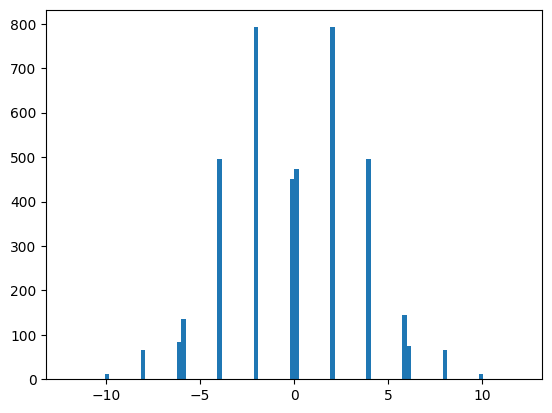

[ 12. -12. -10.  10.  10. -10. -10.  10.  10.  10.]


In [21]:
plt.hist(eigenvalues_cart, bins=100)
# plt.xlim(-12, 30)
plt.show()
print(eigenvalues_cart[:10])

In [105]:
import numpy as np
import networkx as nx

def generate_quotient_matrix(adj_G1, num_blocks_G2, coupling_l):
    """
    Generates the quotient matrix Q for the Cartesian product G1 Box G2,
    following the equitable partition defined in the text.
    
    Constraints:
    - Diagonal entries are set to 0 (No self-loops).
    - Rows of original blocks are effectively summed via the Kronecker product logic.
    
    Parameters:
    -----------
    adj_G1 : np.ndarray
        Adjacency matrix of the first graph G1 (size n x n).
    num_blocks_G2 : int
        The number of subgraphs (blocks) in the partition of G2 (size m).
    coupling_l : float or np.ndarray
        The coupling regularity (edges from a node in block j to block k).
        - If scalar: Assumes uniform coupling 'l' between all distinct blocks.
        - If matrix: Uses a specific (m x m) coupling matrix.

    Returns:
    --------
    Q : np.ndarray
        The quotient matrix (size n*m x n*m) with 0 diagonal.
    """
    
    n = adj_G1.shape[0]        # Size of G1
    m = num_blocks_G2          # Number of blocks in G2
    
    # 1. Construct B_G2 (The quotient interaction of G2)
    # This represents the "vertical" connectivity (edges within G2 components).
    if isinstance(coupling_l, (int, float)):
        # Case: Uniform coupling 'l' between all distinct blocks
        B_G2 = np.full((m, m), coupling_l, dtype=float)
    else:
        # Case: Explicit coupling matrix provided
        B_G2 = np.array(coupling_l, dtype=float)

    # CONSTRAINT: Remove self-loops (internal k-regularity)
    # We force the diagonal of the G2 component to 0.
    np.fill_diagonal(B_G2, 0)

    # 2. Construct Q using the Cartesian Product Tensor Sum
    # The adjacency matrix of a Cartesian product quotient is:
    # Q = A(G1) (tensor) I_m  +  I_n (tensor) B_G2
    
    # Term 1: G1 neighbors (Horizontal connections)
    # Encodes that a node (u, j) connects to (v, j) if u~v in G1.
    term_horizontal = np.kron(adj_G1, np.eye(m))
    
    # Term 2: G2 neighbors (Vertical/Coupling connections)
    # Encodes that a node (u, j) connects to 'l' nodes in (u, k) if j~k in G2.
    term_vertical = np.kron(np.eye(n), B_G2)
    
    # Sum components
    Q = term_horizontal + term_vertical
    
    # Final check to ensure diagonal is purely 0
    np.fill_diagonal(Q, 0)
    
    return Q

# --- Example Usage ---

# 1. Define G1 (e.g., a Triangle / K3)
G1 = nx.complete_graph(3)
A_G1 = coupled_matrix_a#nx.to_numpy_array(G1)

# 2. Define Parameters from your text/PDF
# Note: 'size_of_subgraphs' is NOT needed for the quotient matrix itself, 
# only for the full graph construction. The quotient only cares about counts (l).
num_blocks = 4   # m
coupling_l = 1   # l (edges between blocks)

# 3. Generate Matrix
Q_matrix = generate_quotient_matrix(A_G1, num_blocks, coupling_l)

print(f"Quotient Matrix Shape: {Q_matrix.shape}")
print("Quotient Matrix (Top Left 8x8 slice):")
print(len(Q_matrix))

Quotient Matrix Shape: (32, 32)
Quotient Matrix (Top Left 8x8 slice):
32


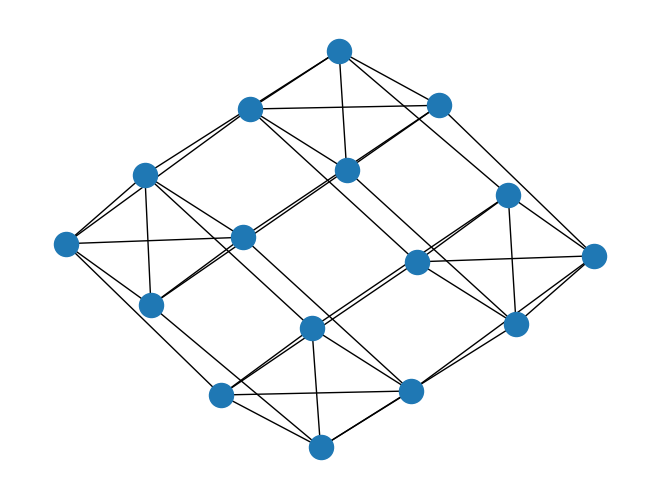

In [95]:
nx.draw(nx.from_numpy_array(Q_matrix))

In [193]:
import numpy as np

def get_quotient_matrix_row_sum(adj_A, block_size):
    """
    Transforms the full adjacency matrix A into the quotient matrix Q
    using the ROW SUM (standard Divisor Matrix definition).
    
    This represents the number of neighbors a single node in Block i 
    has in Block j.
    
    Parameters:
    - adj_A: The full Adjacency Matrix (assumed saved locally)
    - block_size: The size of each partition cell
    """
    n = adj_A.shape[0]
    # Ensure block_size divides n
    if n % block_size != 0:
        raise ValueError(f"Block size {block_size} does not evenly divide matrix size {n}.")
        
    num_blocks = n // block_size
    
    # Initialize the Quotient Matrix
    Q = np.zeros((num_blocks, num_blocks))
    
    # Loop over each block
    for i in range(num_blocks):
        for j in range(num_blocks):
            # Extract the submatrix connecting Block i to Block j
            submatrix = adj_A[i*block_size : (i+1)*block_size, 
                              j*block_size : (j+1)*block_size]
            
            # EQUITABLE PARTITION LOGIC:
            # In a valid equitable partition, every row in this submatrix 
            # sums to the same value. We take the sum of the first row.
            weight = np.sum(submatrix[0, :])
            
            # Set the value in the quotient matrix
            Q[i, j] = weight
            
    # Remove self-loops (Diagonal = 0)
    np.fill_diagonal(Q, 0)
    
    return Q

# --- INPUT DATA ---
# (I am pasting the matrices you provided in the prompt)
A = nx.to_numpy_array(P_cart)

B_target = nx.to_numpy_array(P)

# --- TRANSFORM ---
# The original graph has 36 nodes. The target has 12.
# We infer the block size is 36 / 12 = 3.

Q_zero_diag = get_quotient_matrix_row_sum(A, block_size=10)


In [194]:
def get_quotient_matrix_row_sum(adj_A, block_size):
    """
    Transforms the full adjacency matrix A into the quotient matrix Q
    using the ROW SUM (standard Divisor Matrix definition).
    
    This represents the number of neighbors a single node in Block i 
    has in Block j.
    
    Parameters:
    - adj_A: The full Adjacency Matrix (assumed saved locally)
    - block_size: The size of each partition cell
    """
    n = adj_A.shape[0]
    # Ensure block_size divides n
    if n % block_size != 0:
        raise ValueError(f"Block size {block_size} does not evenly divide matrix size {n}.")
        
    num_blocks = n // block_size
    
    # Initialize the Quotient Matrix
    Q = np.zeros((num_blocks, num_blocks))
    
    # Loop over each block
    for i in range(num_blocks):
        for j in range(num_blocks):
            # Extract the submatrix connecting Block i to Block j
            submatrix = adj_A[i*block_size : (i+1)*block_size, 
                              j*block_size : (j+1)*block_size]
            
            # EQUITABLE PARTITION LOGIC:
            # In a valid equitable partition, every row in this submatrix 
            # sums to the same value. We take the sum of the first row.
            weight = np.sum(submatrix[0, :])
            
            # Set the value in the quotient matrix
            Q[i, j] = weight
            
    # Remove self-loops (Diagonal = 0)
    # np.fill_diagonal(Q, 0)
    
    return Q

# --- INPUT DATA ---
# (I am pasting the matrices you provided in the prompt)
A = nx.to_numpy_array(P_cart)

B_target = nx.to_numpy_array(P)

# --- TRANSFORM ---
# The original graph has 36 nodes. The target has 12.
# We infer the block size is 36 / 12 = 3.
Q_loop = get_quotient_matrix_row_sum(A, block_size=10)

In [ ]:
# Get adjacency matrix
adj_matrix_cart_diag = Q_zero_diag
adj_matrix_cart_loop = Q_loop

# # Compute eigenvalues and eigenvectors
eigenvalues_cart_diag, eigenvectors_cart_diag = np.linalg.eigh(adj_matrix_cart_diag)
eigenvalues_cart_loop, eigenvectors_cart_loop = np.linalg.eigh(adj_matrix_cart_loop)

# # Sort by eigenvalue magnitude
idx_diag = eigenvalues_cart_diag.argsort()[::-1]
idx_loop = eigenvalues_cart_loop.argsort()[::-1]

eigenvalues_cart_diag = eigenvalues_cart_diag[idx_diag]
vectors_cart_diag = eigenvectors_cart_diag[:, idx_diag]

eigenvalues_cart_loop = eigenvalues_cart_loop[idx_loop]
vectors_cart_loop = eigenvectors_cart_loop[:, idx_loop]
